# Exploratory Feature Analysis & Data Cleaning

This notebook performs data cleaning and exploratory analytics on the engineered features in `final_dataset.csv`.

## Objectives:
1. **Data Cleaning**: Handle missing values, duplicate records, and check for correct data types.
2. **Exploratory Data Analysis (EDA)**:
   - Identify distribution of target variable `is_delayed`.
   - Calculate correlations among numerical features.
   - Explore relationships between product characteristics, delivery times, and price ratios.
   - Track delivery delays by category and temporal attributes.
3. **Clean Dataset Export**: Export the clean version of the dataset for downstream modeling.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for high-quality aesthetics
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 12

## 1. Load the Dataset

In [2]:
# Load the dataset
dataset_path = "../Data/processed/final_dataset.csv"
print(f"Loading data from {dataset_path}...")

df = pd.read_csv(dataset_path)
print(f"Dataset shape: {df.shape}")
df.head()

Loading data from ../Data/processed/final_dataset.csv...


Dataset shape: (604742, 15)


,order_id,product_id,seller_id,price,freight_value,product_category_name,product_weight_g,product_volume_cm3,is_same_state,purchase_month,purchase_day_of_week,purchase_hour,estimated_delivery_time_days,delivery_time_days,is_delayed
0,001c85b5f68d2be0cb0797afc9e8ce9a,84f456958365164420cfc80fbe4c7fab,4a3ca9315b744ce9f8e9374361493884,99.0,13.71,cama_mesa_banho,1550.0,20944.0,1,11,4,19.0,19.194931,27.971088,1.0
1,001c85b5f68d2be0cb0797afc9e8ce9a,84f456958365164420cfc80fbe4c7fab,4a3ca9315b744ce9f8e9374361493884,99.0,13.71,cama_mesa_banho,1550.0,20944.0,1,11,4,19.0,19.194931,27.971088,1.0
2,001c85b5f68d2be0cb0797afc9e8ce9a,84f456958365164420cfc80fbe4c7fab,4a3ca9315b744ce9f8e9374361493884,99.0,13.71,cama_mesa_banho,1550.0,20944.0,1,11,4,19.0,19.194931,27.971088,1.0
3,001c85b5f68d2be0cb0797afc9e8ce9a,84f456958365164420cfc80fbe4c7fab,4a3ca9315b744ce9f8e9374361493884,99.0,13.71,cama_mesa_banho,1550.0,20944.0,1,11,4,19.0,19.194931,27.971088,1.0
4,001c85b5f68d2be0cb0797afc9e8ce9a,84f456958365164420cfc80fbe4c7fab,4a3ca9315b744ce9f8e9374361493884,99.0,13.71,cama_mesa_banho,1550.0,20944.0,1,11,4,19.0,19.194931,27.971088,1.0


## 2. Profiling & Data Cleaning

Let's analyze missing values and duplicates to clean the dataset.

In [3]:
# Check for nulls
print("--- Missing Values count ---")
print(df.isnull().sum())

# Check for exact duplicate rows
duplicate_count = df.duplicated().sum()
print(f"\nNumber of exact duplicate rows: {duplicate_count}")
print(f"Percentage of duplicates: {duplicate_count / len(df) * 100:.2f}%")

--- Missing Values count ---
order_id                           0
product_id                         0
seller_id                          0
price                              0
freight_value                      0
product_category_name           8672
product_weight_g                   0
product_volume_cm3                 0
is_same_state                      0
purchase_month                     0
purchase_day_of_week               0
purchase_hour                      1
estimated_delivery_time_days       1
delivery_time_days                 1
is_delayed                         1
dtype: int64



Number of exact duplicate rows: 587492
Percentage of duplicates: 97.15%


### Observations & Action Plan:
- `product_category_name` has 8,672 missing values. We will fill these with `'unknown'`.
- `purchase_hour`, `estimated_delivery_time_days`, `delivery_time_days`, and `is_delayed` have 1 missing row. We will drop this single incomplete row.
- The dataset contains a high count of exact duplicate rows (587,492 duplicates out of 604,742 records). This is caused by duplicate rows in the raw SQL database tables (`orders`, `customers`, etc.) creating a Cartesian product when joining. We will remove these duplicates to represent clean individual transactions.
- Convert appropriate columns (`purchase_hour`, `is_delayed`, `purchase_month`, `purchase_day_of_week`, `is_same_state`) to integers.

In [4]:
# 1. Fill missing product categories
df['product_category_name'] = df['product_category_name'].fillna('unknown')

# 2. Drop rows with null values in critical features (only 1 row)
df = df.dropna(subset=['purchase_hour', 'estimated_delivery_time_days', 'delivery_time_days', 'is_delayed'])

# 3. Handle duplicates
df_cleaned = df.drop_duplicates().reset_index(drop=True)

# 4. Cast appropriate data types
int_cols = ['purchase_hour', 'is_delayed', 'is_same_state', 'purchase_month', 'purchase_day_of_week']
df_cleaned[int_cols] = df_cleaned[int_cols].astype(int)

print(f"Cleaned dataset shape: {df_cleaned.shape}")
print(f"Removed {df.shape[0] - df_cleaned.shape[0]} rows of duplicates and nulls.")

Cleaned dataset shape: (17249, 15)
Removed 587492 rows of duplicates and nulls.


## 3. Exploratory Data Analytics (EDA)

### 3.1 Target Variable Analysis (`is_delayed`)
Let's see the proportion of delayed deliveries in the cleaned dataset.

/tmp/ipykernel_61180/641698025.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=delay_counts.index, y=delay_counts.values, palette='coolwarm')


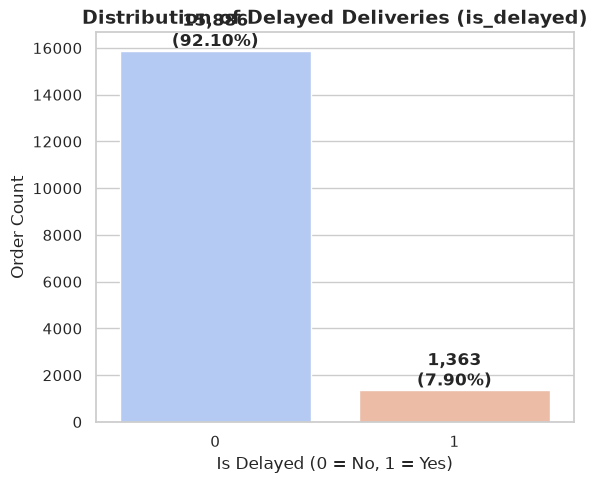

In [5]:
delay_counts = df_cleaned['is_delayed'].value_counts()
delay_pct = df_cleaned['is_delayed'].value_counts(normalize=True) * 100

plt.figure(figsize=(6, 5))
sns.barplot(x=delay_counts.index, y=delay_counts.values, palette='coolwarm')
plt.title('Distribution of Delayed Deliveries (is_delayed)', fontsize=14, fontweight='bold')
plt.xlabel('Is Delayed (0 = No, 1 = Yes)', fontsize=12)
plt.ylabel('Order Count', fontsize=12)
for i, (count, pct) in enumerate(zip(delay_counts.values, delay_pct.values)):
    plt.text(i, count + 200, f"{count:,}\n({pct:.2f}%)", ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

### 3.2 Correlation Analysis
Let's find the linear correlation among our numerical features.

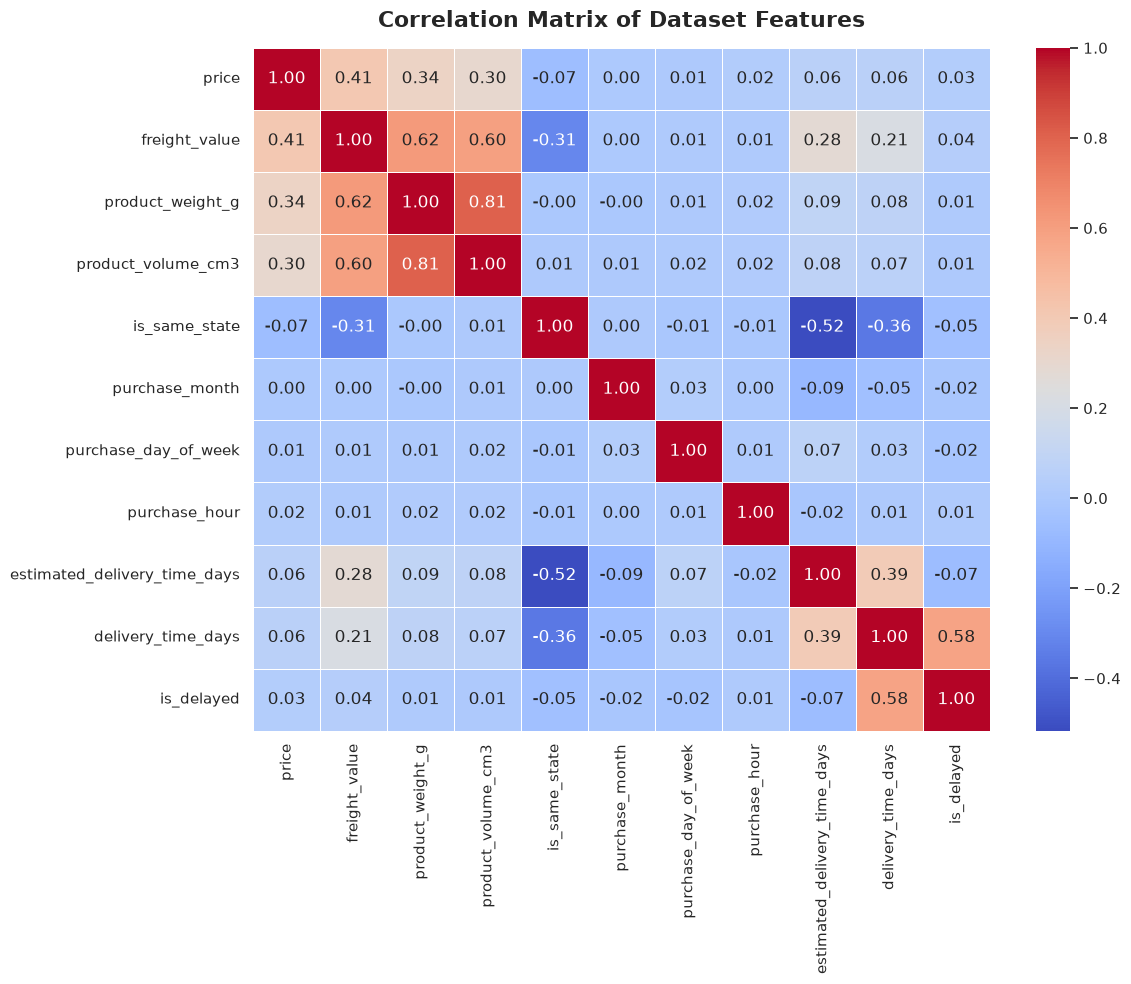

In [6]:
num_cols = df_cleaned.select_dtypes(include=[np.number]).columns
corr_matrix = df_cleaned[num_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix of Dataset Features', fontsize=16, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

### 3.3 Actual vs. Estimated Delivery Time
Let's compare actual delivery times vs estimated delivery times.

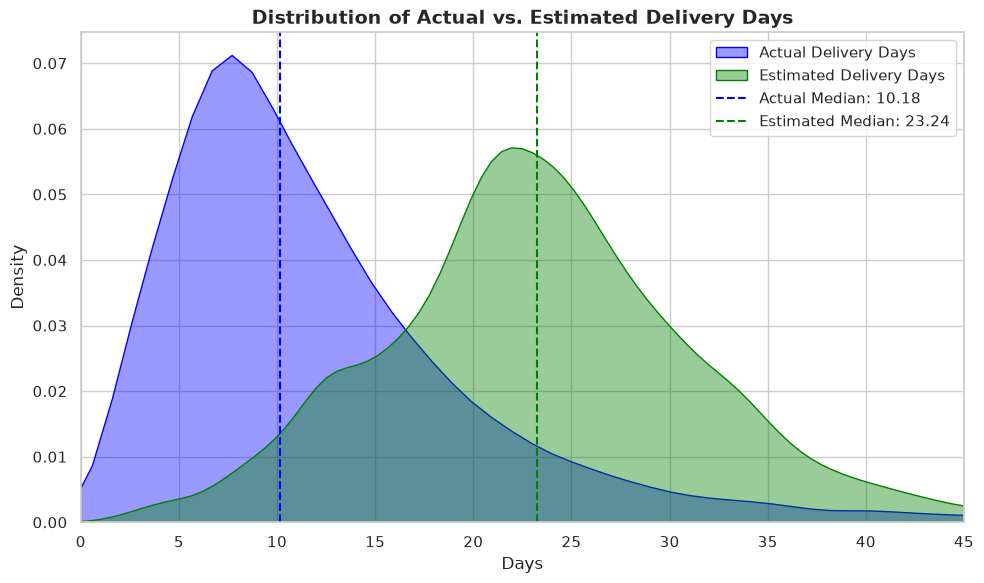

In [7]:
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df_cleaned, x='delivery_time_days', fill=True, label='Actual Delivery Days', color='blue', alpha=0.4)
sns.kdeplot(data=df_cleaned, x='estimated_delivery_time_days', fill=True, label='Estimated Delivery Days', color='green', alpha=0.4)
plt.axvline(df_cleaned['delivery_time_days'].median(), color='blue', linestyle='--', label=f"Actual Median: {df_cleaned['delivery_time_days'].median():.2f}")
plt.axvline(df_cleaned['estimated_delivery_time_days'].median(), color='green', linestyle='--', label=f"Estimated Median: {df_cleaned['estimated_delivery_time_days'].median():.2f}")
plt.xlim(0, 45)
plt.title('Distribution of Actual vs. Estimated Delivery Days', fontsize=14, fontweight='bold')
plt.xlabel('Days', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

### 3.4 Freight-to-Price Ratio
Let's analyze how the freight cost compares relative to the product price.

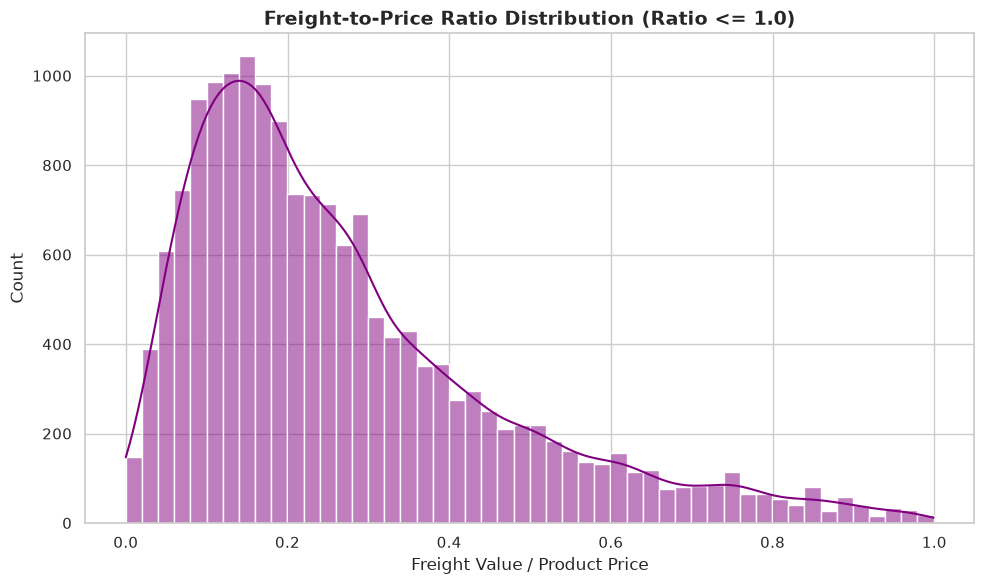

In [8]:
df_cleaned['freight_to_price_ratio'] = df_cleaned['freight_value'] / df_cleaned['price']

plt.figure(figsize=(10, 6))
sns.histplot(data=df_cleaned[df_cleaned['freight_to_price_ratio'] <= 1], x='freight_to_price_ratio', bins=50, kde=True, color='purple')
plt.title('Freight-to-Price Ratio Distribution (Ratio <= 1.0)', fontsize=14, fontweight='bold')
plt.xlabel('Freight Value / Product Price', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.tight_layout()
plt.show()

### 3.5 Delivery Delay Rate by Product Category
Let's look at the product categories with the highest delay rates (among categories with > 50 orders).

/tmp/ipykernel_61180/597518865.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=popular_cats.head(15), x='delay_rate', y='product_category_name', palette='Oranges_r')


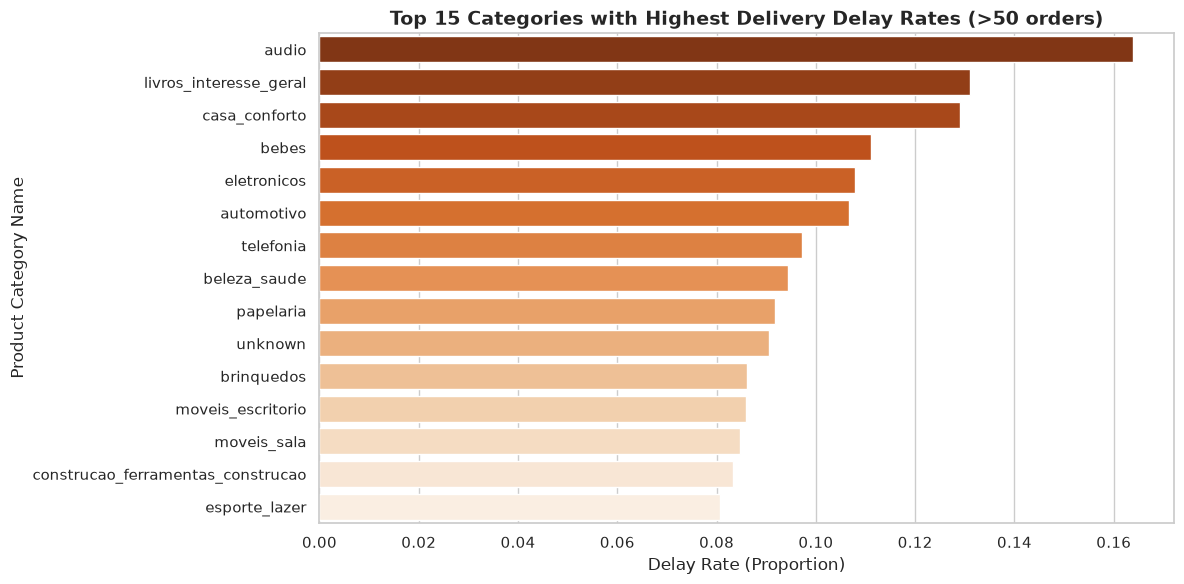

In [9]:
cat_stats = df_cleaned.groupby('product_category_name').agg(
    order_count=('order_id', 'count'),
    mean_price=('price', 'mean'),
    mean_freight=('freight_value', 'mean'),
    mean_delivery_time=('delivery_time_days', 'mean'),
    delay_rate=('is_delayed', 'mean')
).reset_index()

# Filter for popular categories
popular_cats = cat_stats[cat_stats['order_count'] > 50].sort_values(by='delay_rate', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(data=popular_cats.head(15), x='delay_rate', y='product_category_name', palette='Oranges_r')
plt.title('Top 15 Categories with Highest Delivery Delay Rates (>50 orders)', fontsize=14, fontweight='bold')
plt.xlabel('Delay Rate (Proportion)', fontsize=12)
plt.ylabel('Product Category Name', fontsize=12)
plt.tight_layout()
plt.show()

### 3.6 Temporal Factors influencing Delivery Delays
Let's analyze delay rates based on purchase day of the week and purchase hour.

/tmp/ipykernel_61180/585088754.py:4: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(ax=axes[0], data=df_cleaned, x='purchase_day_of_week', y='is_delayed', ci=None, palette='viridis')
/tmp/ipykernel_61180/585088754.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[0], data=df_cleaned, x='purchase_day_of_week', y='is_delayed', ci=None, palette='viridis')
/tmp/ipykernel_61180/585088754.py:10: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(ax=axes[1], data=df_cleaned, x='purchase_hour', y='is_delayed', ci=None, marker='o', color='red')


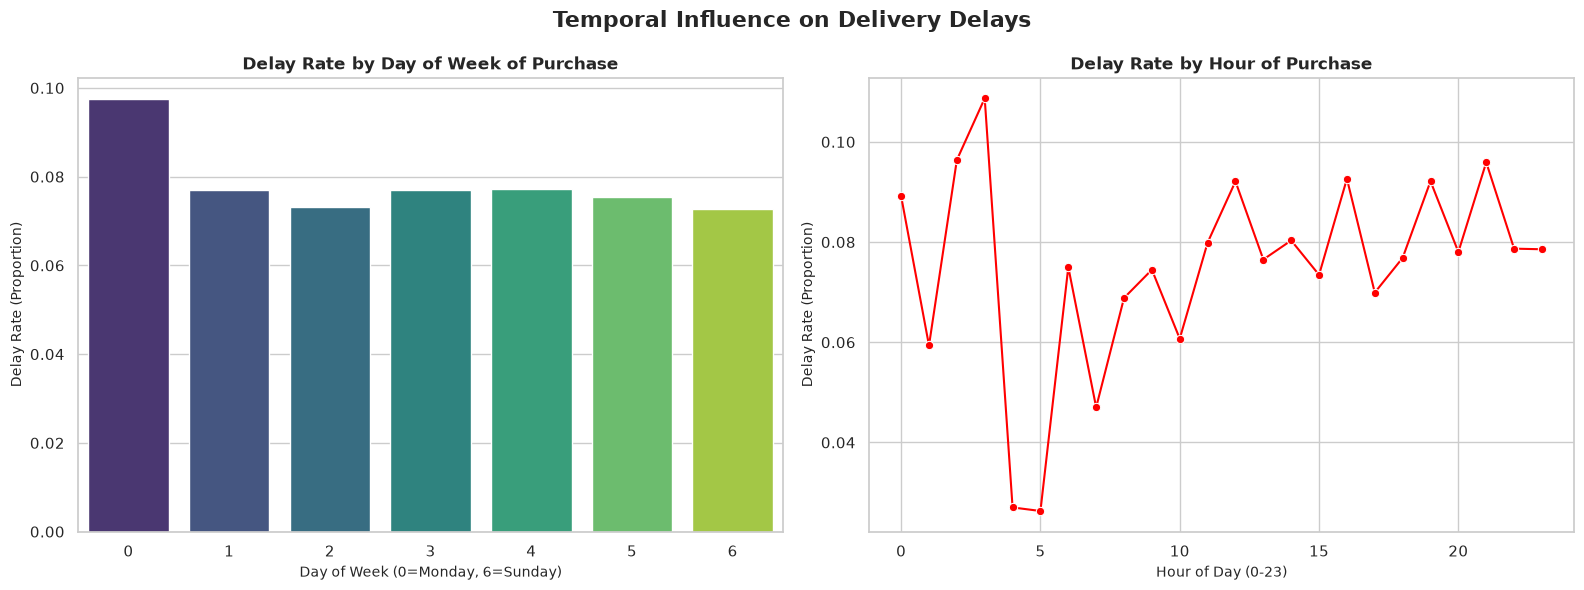

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Delay by Day of the Week
sns.barplot(ax=axes[0], data=df_cleaned, x='purchase_day_of_week', y='is_delayed', ci=None, palette='viridis')
axes[0].set_title('Delay Rate by Day of Week of Purchase', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Day of Week (0=Monday, 6=Sunday)', fontsize=10)
axes[0].set_ylabel('Delay Rate (Proportion)', fontsize=10)

# Delay by Purchase Hour
sns.lineplot(ax=axes[1], data=df_cleaned, x='purchase_hour', y='is_delayed', ci=None, marker='o', color='red')
axes[1].set_title('Delay Rate by Hour of Purchase', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Hour of Day (0-23)', fontsize=10)
axes[1].set_ylabel('Delay Rate (Proportion)', fontsize=10)

plt.suptitle('Temporal Influence on Delivery Delays', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Export Cleaned Dataset

Save the cleaned dataset to `cleaned_dataset.csv` for use in modeling.

Original class distribution:
is_delayed
0    15886
1     1363
Name: count, dtype: int64


Balanced class distribution:
is_delayed
1    15886
0    15886
Name: count, dtype: int64


/tmp/ipykernel_61180/3169286153.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_temp, ax=axes[0], palette='viridis')
/tmp/ipykernel_61180/3169286153.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_res, ax=axes[1], palette='viridis')


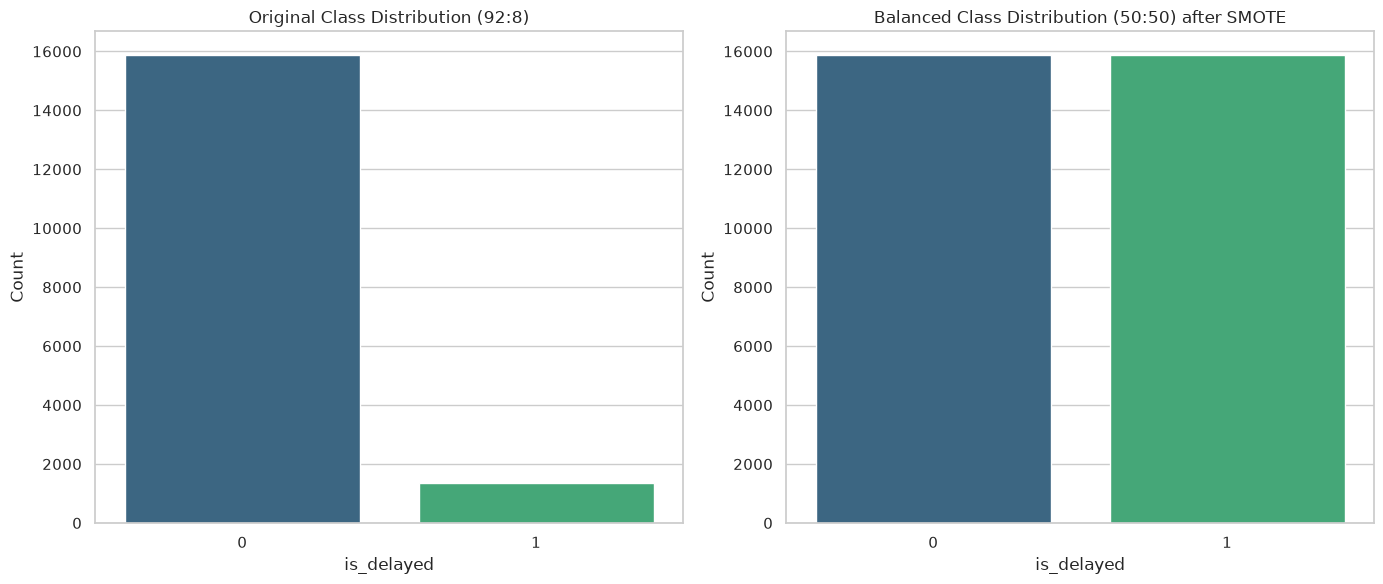

Balanced dataset exported successfully to ../Data/processed/cleaned_dataset.csv!


In [11]:
from imblearn.over_sampling import SMOTENC
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Drop high cardinality unique identifiers not needed for model training
cols_to_drop = ['order_id', 'product_id', 'seller_id']
df_for_smote = df_cleaned.drop(columns=[col for col in cols_to_drop if col in df_cleaned.columns], errors='ignore')
df_for_smote = df_for_smote.replace([np.inf, -np.inf], np.nan).dropna()

# 2. Identify categorical features
categorical_features = ['product_category_name', 'is_same_state', 'purchase_month', 'purchase_day_of_week', 'purchase_hour']
categorical_indices = [df_for_smote.columns.get_loc(col) for col in categorical_features if col in df_for_smote.columns]

X_temp = df_for_smote.drop(columns=['is_delayed'])
y_temp = df_for_smote['is_delayed']

print("Original class distribution:")
print(y_temp.value_counts())

# 3. Run SMOTENC to balance the target variable (is_delayed)
smote_nc = SMOTENC(categorical_features=categorical_indices, random_state=42)
X_res, y_res = smote_nc.fit_resample(X_temp, y_temp)

df_balanced = X_res.copy()
df_balanced['is_delayed'] = y_res

print("Balanced class distribution:")
print(y_res.value_counts())

# 4. Visualize the SMOTE balancing
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.countplot(x=y_temp, ax=axes[0], palette='viridis')
axes[0].set_title('Original Class Distribution (92:8)')
axes[0].set_xlabel('is_delayed')
axes[0].set_ylabel('Count')

sns.countplot(x=y_res, ax=axes[1], palette='viridis')
axes[1].set_title('Balanced Class Distribution (50:50) after SMOTE')
axes[1].set_xlabel('is_delayed')
axes[1].set_ylabel('Count')

plt.tight_layout()
import os
os.makedirs('../plots', exist_ok=True)
plt.savefig('../plots/smote_balancing_comparison.png', dpi=300)
plt.show()

# 5. Export the balanced dataset
cleaned_csv_path = "../Data/processed/cleaned_dataset.csv"
df_balanced.to_csv(cleaned_csv_path, index=False)
print(f"Balanced dataset exported successfully to {cleaned_csv_path}!")